# Импорты и настройки

In [39]:
# coding: utf-8
# наше всё
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.colors as mcolors

#настройки pandas, с которыми лучше почти всегда
pd.set_option('display.max_rows', 45000)
pd.set_option('display.max_columns', 50000)
pd.set_option('display.max_colwidth', 5000)

# Получение данных и проверки

In [3]:
sorce_df = pd.read_csv('visual_challenge_ver_0.csv')
sorce_df['calendar_date'] = pd.to_datetime(sorce_df['calendar_date'])

In [4]:
sorce_df.sample(3)

,art_id,calendar_date,user_visits,sids_visits,events_visits,sales_qty,revenue,avg_sales_catalogue_price,avg_dim_price
4,243463,2026-02-16,55,72,82,6.0,372.0,60.0,59.9
17,86630365,2026-02-16,182,227,317,4.0,2512.0,679.0,749.0
47,142416959,2026-02-20,30,31,33,1.0,182.0,260.0,289.0


In [5]:
sorce_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   art_id                     52 non-null     int64         
 1   calendar_date              52 non-null     datetime64[ns]
 2   user_visits                52 non-null     int64         
 3   sids_visits                52 non-null     int64         
 4   events_visits              52 non-null     int64         
 5   sales_qty                  52 non-null     float64       
 6   revenue                    52 non-null     float64       
 7   avg_sales_catalogue_price  52 non-null     float64       
 8   avg_dim_price              52 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(4)
memory usage: 3.8 KB


In [6]:
sorce_df.describe()

,art_id,calendar_date,user_visits,sids_visits,events_visits,sales_qty,revenue,avg_sales_catalogue_price,avg_dim_price
count,5.200000e+01,52,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,7.905905e+07,2026-02-18 00:00:00,68.211538,83.519231,155.423077,3.346154,1007.423077,451.192308,474.801923
min,2.434630e+05,2026-02-12 00:00:00,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6.503364e+07,2026-02-15 00:00:00,17.500000,17.750000,24.750000,1.000000,254.500000,60.000000,59.900000
50%,8.678788e+07,2026-02-18 00:00:00,47.500000,55.000000,75.000000,2.500000,446.000000,260.000000,289.000000
75%,1.008133e+08,2026-02-21 00:00:00,88.500000,121.750000,263.000000,6.000000,1504.750000,679.000000,749.000000
max,1.424170e+08,2026-02-24 00:00:00,243.000000,277.000000,778.000000,11.000000,4034.000000,2199.000000,2199.000000
std,5.135294e+07,NaN,69.891046,84.940692,195.931395,2.949806,1195.902159,632.084384,637.299389


In [7]:
sorce_df['art_id'].value_counts()

art_id
243463       13
86630365     13
86945401     13
142416959    13
Name: count, dtype: int64

# Задача 1
Построить подневную динамику выручки одной книжки

In [9]:
sorce_df['revenue'].sample(3)

12     429.0
34    1100.0
30    1100.0
Name: revenue, dtype: float64

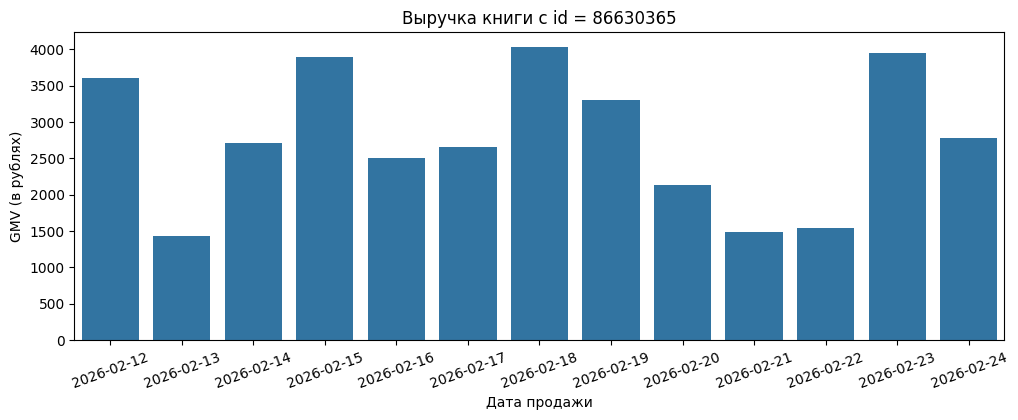

In [45]:
# current_art = np.random.choice(sorce_df['art_id'].unique())
current_art = 86630365

plt.figure(figsize=(12, 4))
ax = sns.barplot(
    x='calendar_date', 
    y='revenue', 
    data=sorce_df[sorce_df['art_id'] == current_art],
    # graph color  tab10[4]
    # color = mcolors.viridis(0.4)
    # palette = 'tab10'
    )

plt.title(f'Выручка книги c id = {current_art}')
plt.xlabel('Дата продажи')
plt.ylabel('GMV (в рублях)')
axt = plt.xticks(rotation=20)

In [ ]:
sns.color_palette('tab10')[4]   

(0.5803921568627451, 0.403921568627451, 0.7411764705882353)

# Задача 2
Показать взаимное влияние числа покупок и среднего чека в динамике

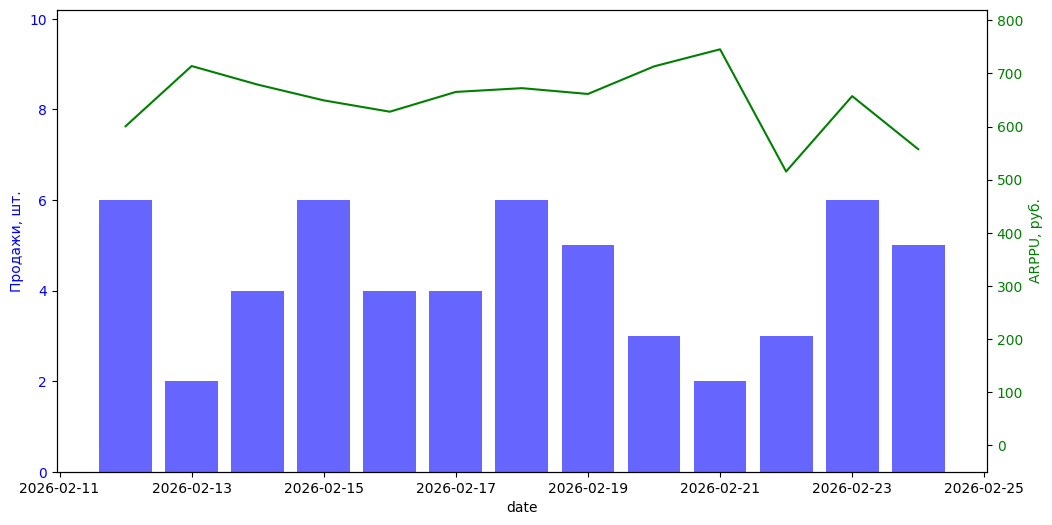

In [96]:
current_art = 86630365
sorce_df = sorce_df.sort_values(by='calendar_date')
sorce_df['ARPPU'] = sorce_df['revenue'] / sorce_df['sales_qty']

work_df = sorce_df[sorce_df['art_id'] == current_art]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(work_df['calendar_date'], work_df['sales_qty'], color='b', alpha=0.6, label='date')
ax1.set_xlabel('date')
ax1.set_ylabel('Продажи, шт.', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylim(0, max(work_df['sales_qty'])*1.7)

ax2 = ax1.twinx()
ax2.plot(work_df['calendar_date'], work_df['ARPPU'], color='green', label='metric2')
ax2.set_ylabel('ARPPU, руб.', color='green')
ax2.set_ylim(-50, max(work_df['ARPPU'])*1.1)
ax2.tick_params(axis='y', labelcolor='green')

# формат даты 26 feb каждый день
import matplotlib.dates as mdates
# ax1.xaxis.set_major_locator(mdates.DayLocator(byhday=e))

# Задача 3
Максимально компактно показать 3 параметра книжки на одном таймлайне: трафик, цену и выручку.  

In [ ]:
# user_visits
# revenue
# avg_sales_catalogue_price

In [ ]:
243463       13
86630365     13
86945401     13
142416959    13

In [135]:
sorce_df[sorce_df['art_id'] == 243463]['avg_sales_catalogue_price'].describe()

count    13.0
mean     60.0
std       0.0
min      60.0
25%      60.0
50%      60.0
75%      60.0
max      60.0
Name: avg_sales_catalogue_price, dtype: float64

/tmp/ipykernel_7137/2005828555.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  work_df['user_visits_scale'] = (work_df['user_visits'].max() - work_df['user_visits'])


Text(0, 0.5, '')

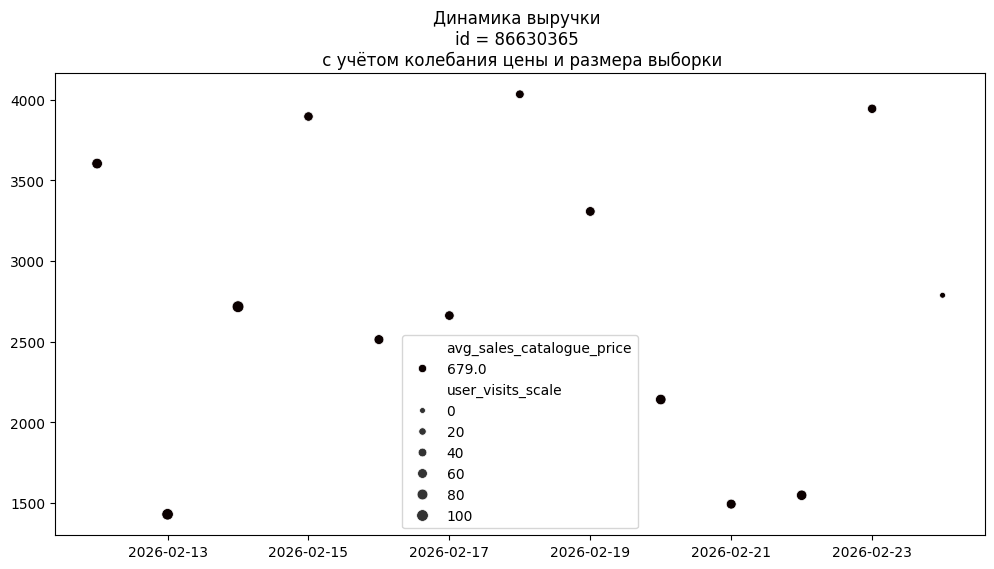

In [143]:
current_art = 86630365

work_df['user_visits_scale'] = (work_df['user_visits'].max() - work_df['user_visits'])

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=work_df,
    x='calendar_date', 
    y='revenue', 
    size=work_df['user_visits_scale'],
    hue='avg_sales_catalogue_price',
    palette='hot',
    # legend=False,
    )
plt.title(f'Динамика выручки \nid = {current_art} \n с учётом колебания цены и размера выборки')
plt.xlabel('')
plt.ylabel('')